In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,Flowers102


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),             
])

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/fish/Fish_Dataset/Fish_Dataset'
model_algo="vgg16"

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size),generator=generator)


In [6]:
valid_size

3600

In [7]:
train_size

14400

In [8]:
# create data loaders
batch_size =64 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=1.3713087118996514,train_accu=0.4110416666666667
Epoch=0,valid_loss=1.380659867392646,valid_accu=0.4011111111111111
0
Epoch=1,train_loss=1.0859418842527602,train_accu=0.5291666666666667
Epoch=1,valid_loss=1.1209620814853245,valid_accu=0.5075
0
Epoch=2,train_loss=0.9157669194539388,train_accu=0.6335416666666667
Epoch=2,valid_loss=0.9287235453393724,valid_accu=0.6308333333333334
0
Epoch=3,train_loss=0.7192109374205271,train_accu=0.7145833333333333
Epoch=3,valid_loss=0.7276485824584961,valid_accu=0.7088888888888889
0
Epoch=4,train_loss=0.614949342807134,train_accu=0.7582638888888888
Epoch=4,valid_loss=0.6556535538037618,valid_accu=0.7441666666666666
0
Epoch=5,train_loss=0.6239431601100498,train_accu=0.7857638888888889
Epoch=5,valid_loss=0.7059459922048781,valid_accu=0.7569444444444444
0
Epoch=6,train_loss=0.44995124578475953,train_accu=0.8317361111111111
Epoch=6,valid_loss=0.5179457269774543,valid_accu=0.8052777777777778
0
Epoch=7,train_loss=0.4337794973452886,train_acc

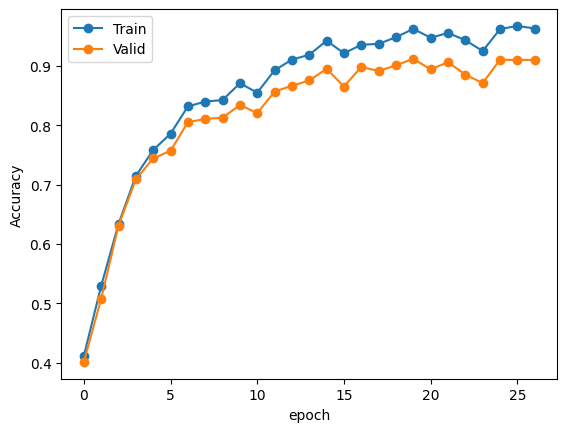

In [9]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_10.pth')

In [10]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.1037272660765383, 0.9624305555555556)

In [11]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.2590095892879698, 0.9119444444444444)

In [12]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [13]:
each_accu=p
each_accu

Black Sea Sprat       0.967296
Gilt-Head Bream       0.984839
Hourse Mackerel       0.973994
Red Mullet            0.963826
Red Sea Bream         0.879332
Sea Bass              0.975487
Shrimp                1.000000
Striped Red Mullet    0.942639
Trout                 0.974619
dtype: float64

In [14]:
each_f1=2*p*r/(p+r)
each_f1

Black Sea Sprat       0.977439
Gilt-Head Bream       0.931302
Hourse Mackerel       0.980979
Red Mullet            0.947273
Red Sea Bream         0.931803
Sea Bass              0.966376
Shrimp                0.997551
Striped Red Mullet    0.952964
Trout                 0.976168
dtype: float64

In [15]:
# targetF=[]
# for top in top_positions:
#     targetF.append(top[0])
#     targetF.append(top[1])
# targetF    

In [16]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [17]:
# targetF=[x  for x in each_f1.nsmallest(90).index.map(trainset.dataset.classess)]
# targetF

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('TandF')
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(541, 13859)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(317, 3283)

In [20]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [21]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [22]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        optim = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    elif(data_name=='0'):
        optim = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.28715381536218854,train_accu=0.8803472222222222
Epoch=0,valid_loss=0.44723390089140996,valid_accu=0.7947222222222222
0
Epoch=1,train_loss=0.2210961487558153,train_accu=0.9186111111111112
Epoch=1,valid_loss=0.3975847348901961,valid_accu=0.8636111111111111
0
Epoch=2,train_loss=0.272265282008383,train_accu=0.8983333333333333
Epoch=2,valid_loss=0.4714847509066264,valid_accu=0.8202777777777778
Epoch=3,train_loss=0.25702997545401257,train_accu=0.9131944444444444
Epoch=3,valid_loss=0.5756410507361094,valid_accu=0.8172222222222222
Epoch=4,train_loss=0.11234458996603887,train_accu=0.9580555555555555
Epoch=4,valid_loss=0.5713362248738607,valid_accu=0.875
0
Epoch=5,train_loss=0.10542222034186124,train_accu=0.970625
Epoch=5,valid_loss=0.5892021200971471,valid_accu=0.9019444444444444
0
Epoch=6,train_loss=0.11589961448891295,train_accu=0.9618055555555556
Epoch=6,valid_loss=0.5089971568187078,valid_accu=0.8738888888888889
Epoch=7,train_loss=0.09204280371467273,train_accu=0.973541

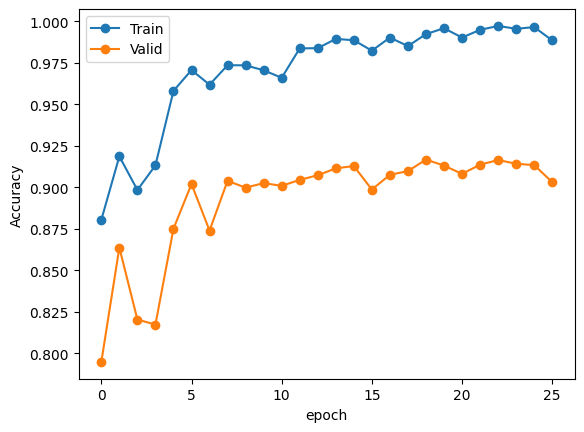

In [23]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=64)
decision_dl = DataLoader(decisionset, batch_size=64,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=64)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,model_0=model_0)

In [24]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.11501133733303552,train_accu=0.9649325348149217
Epoch=0,valid_loss=0.18586055946003327,valid_accu=0.9442583003350594
0
Epoch=1,train_loss=0.10896708591627399,train_accu=0.9655819323183491
Epoch=1,valid_loss=0.2075719840727018,valid_accu=0.9375571123971976
Epoch=2,train_loss=0.0800152466021512,train_accu=0.9734468576376362
Epoch=2,valid_loss=0.19046484979230965,valid_accu=0.9479134937557112
0
Epoch=3,train_loss=0.11370383560317739,train_accu=0.9644274478678115
Epoch=3,valid_loss=0.20969039002933265,valid_accu=0.9345111178799879
Epoch=4,train_loss=0.09602850390771486,train_accu=0.9699834042860235
Epoch=4,valid_loss=0.15135155774782316,valid_accu=0.9515686871763631
0
Epoch=5,train_loss=0.16377242337109954,train_accu=0.9510065661303124
Epoch=5,valid_loss=0.25606769176289107,valid_accu=0.9238501370697533
Epoch=6,train_loss=0.11097299957030891,train_accu=0.9657262428746662
Epoch=6,valid_loss=0.1794974030906966,valid_accu=0.9439537008833384
Epoch=7,train_loss=0.1637995002

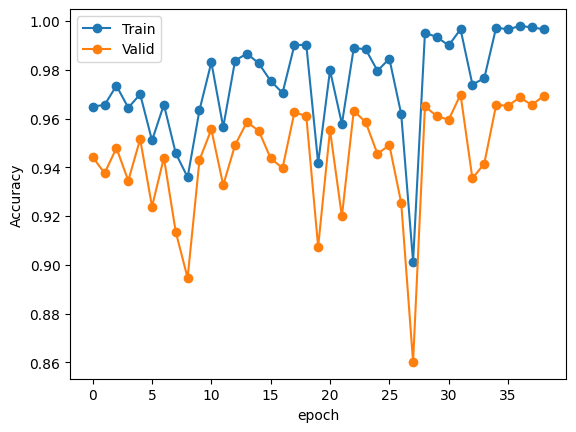

In [25]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.9541012352804159,train_accu=0.6820702402957486
Epoch=0,valid_loss=1.4071274435482566,valid_accu=0.526813880126183
0
Epoch=1,train_loss=0.5746700516910518,train_accu=0.7948243992606284
Epoch=1,valid_loss=1.1621473726790035,valid_accu=0.6088328075709779
0
Epoch=2,train_loss=0.3854180251053653,train_accu=0.8428835489833642
Epoch=2,valid_loss=1.2629784368190105,valid_accu=0.6056782334384858
Epoch=3,train_loss=0.23884711104708548,train_accu=0.9131238447319778
Epoch=3,valid_loss=1.2678015378747454,valid_accu=0.6182965299684543
0
Epoch=4,train_loss=0.11248906215656267,train_accu=0.977818853974122
Epoch=4,valid_loss=1.60256131439931,valid_accu=0.6088328075709779
Epoch=5,train_loss=0.09556923937500074,train_accu=0.966728280961183
Epoch=5,valid_loss=1.9095550846978318,valid_accu=0.6529968454258676
0
Epoch=6,train_loss=0.08073153256571226,train_accu=0.9722735674676525
Epoch=6,valid_loss=1.6631011771102808,valid_accu=0.6151419558359621
Epoch=7,train_loss=0.06331295999328222,tr

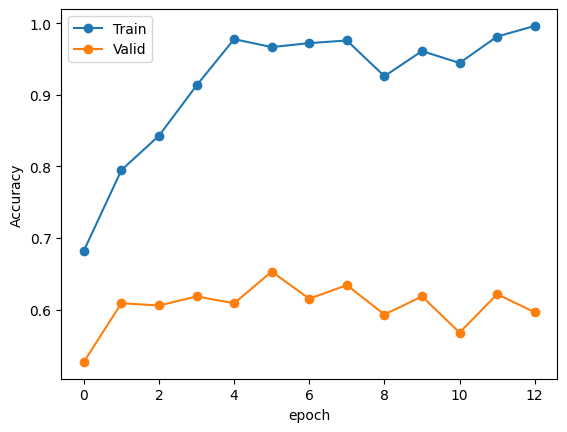

In [26]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [27]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.02209431397017195, 0.993125)

In [28]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(1.024154433108969, 0.9166666666666666)

In [29]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.011418849972286848, 0.9966087019265459)

In [30]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.09556921772562423, 0.966728280961183)

In [31]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.12734256116057763, 0.9698446542796223)

In [32]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.9095552825025204, 0.6529968454258676)

In [33]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d

(0.014580330179208734, 0.9954861111111111)

In [34]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.28427615521074684, 0.9419444444444445, 317)

In [35]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.03630264458673385, 0.9929861111111111, 620, 13780)

In [36]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.38539583696259394, 0.9336111111111111, 105, 3495)

In [37]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [38]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'splitmode={split_mode}')
df

splitmode=TandF


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.103727,0.962431,0.259010,0.911944
1,Model_Decision,0.022094,0.993125,1.024154,0.916667
2,Model_T,0.011419,0.996609,0.127343,0.969845
3,Model_F,0.095569,0.966728,1.909555,0.652997
4,Total_Model,0.036303,0.992986,0.385396,0.933611
5,Total_Model_with_perfect_decision,0.014580,0.995486,0.284276,0.941944


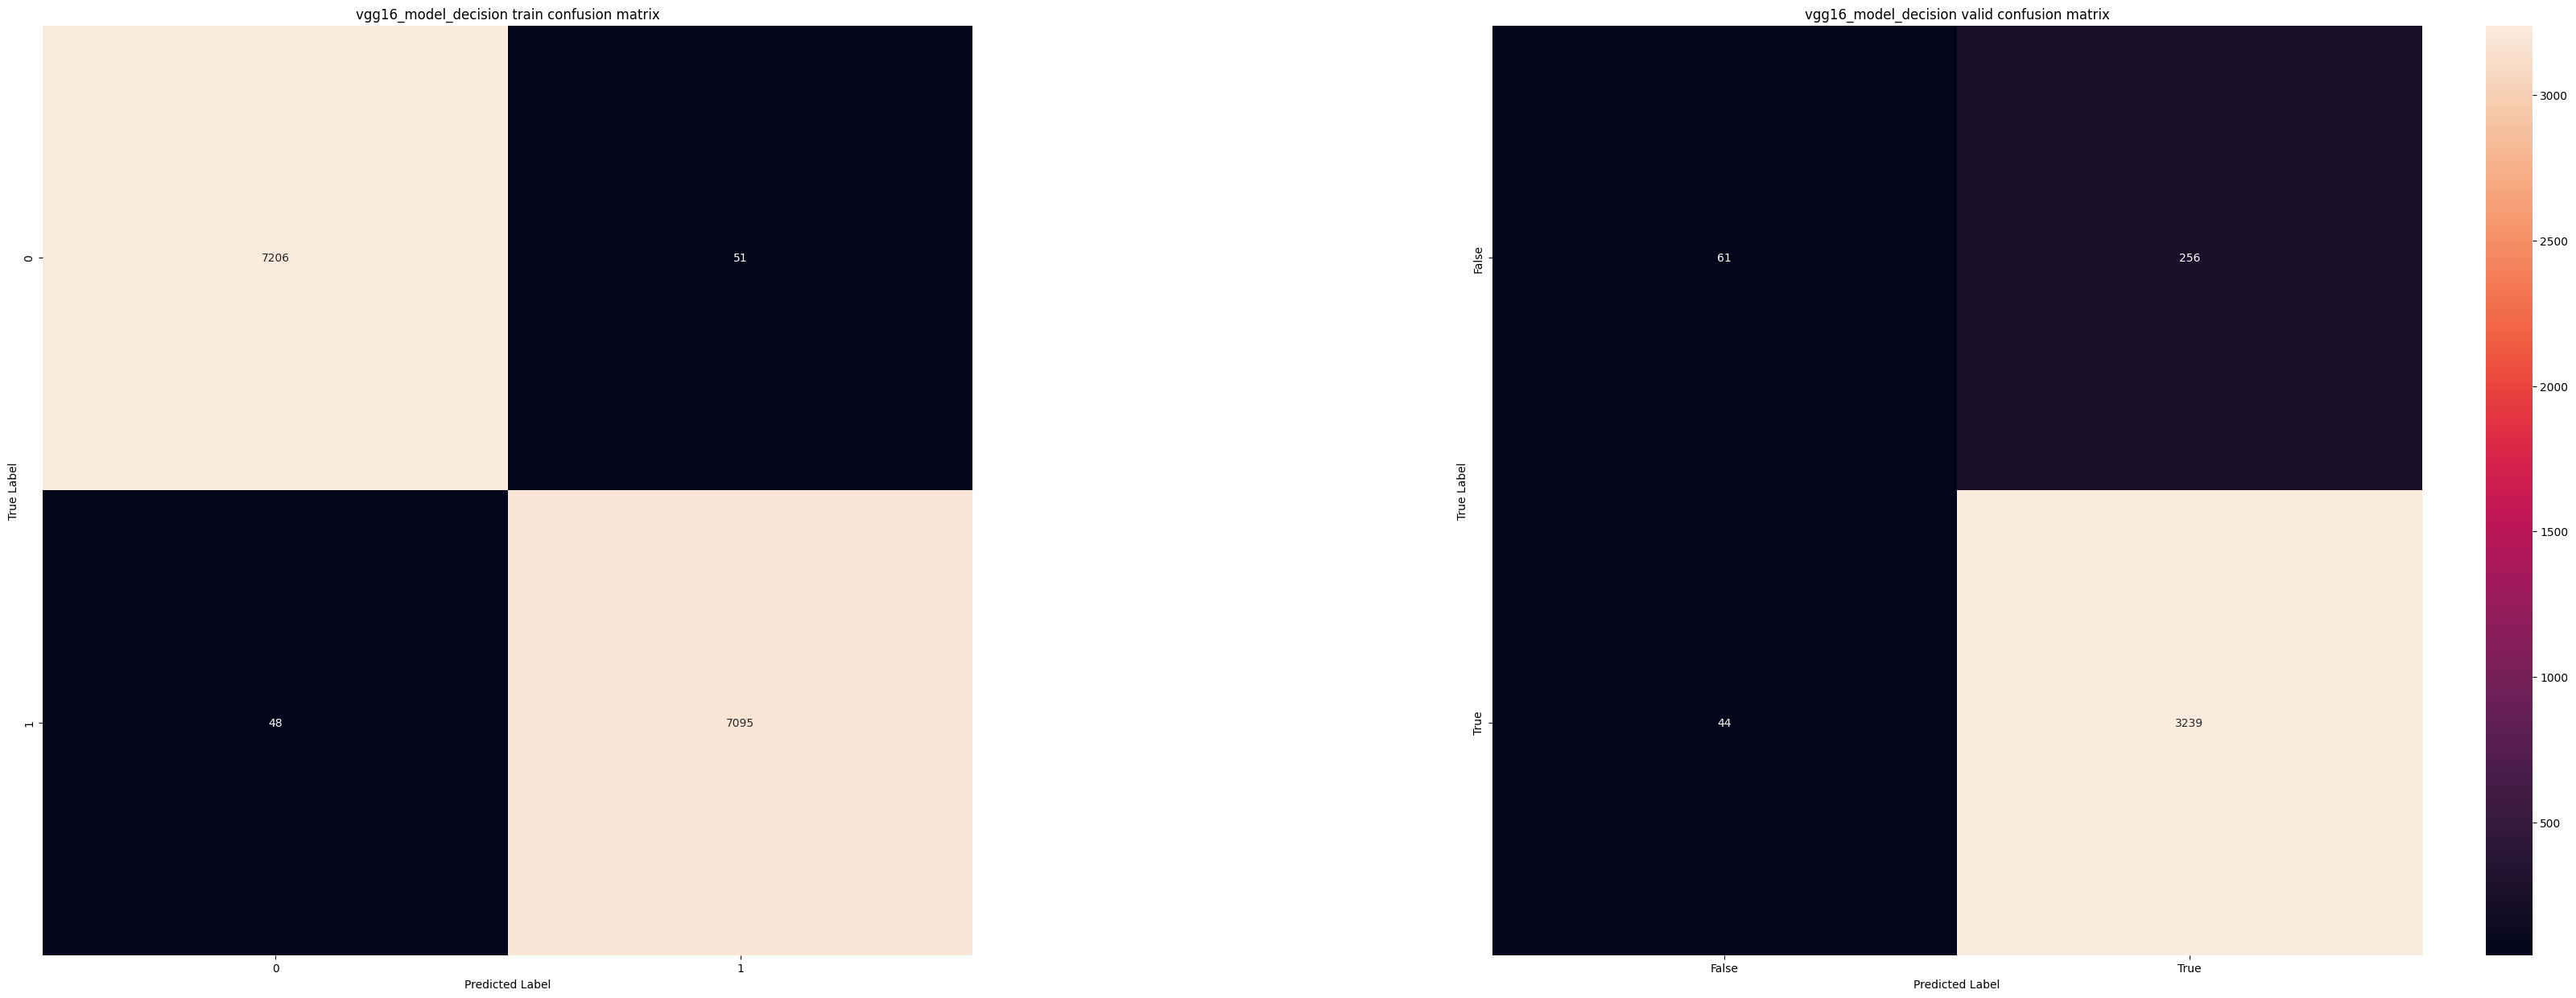

In [39]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

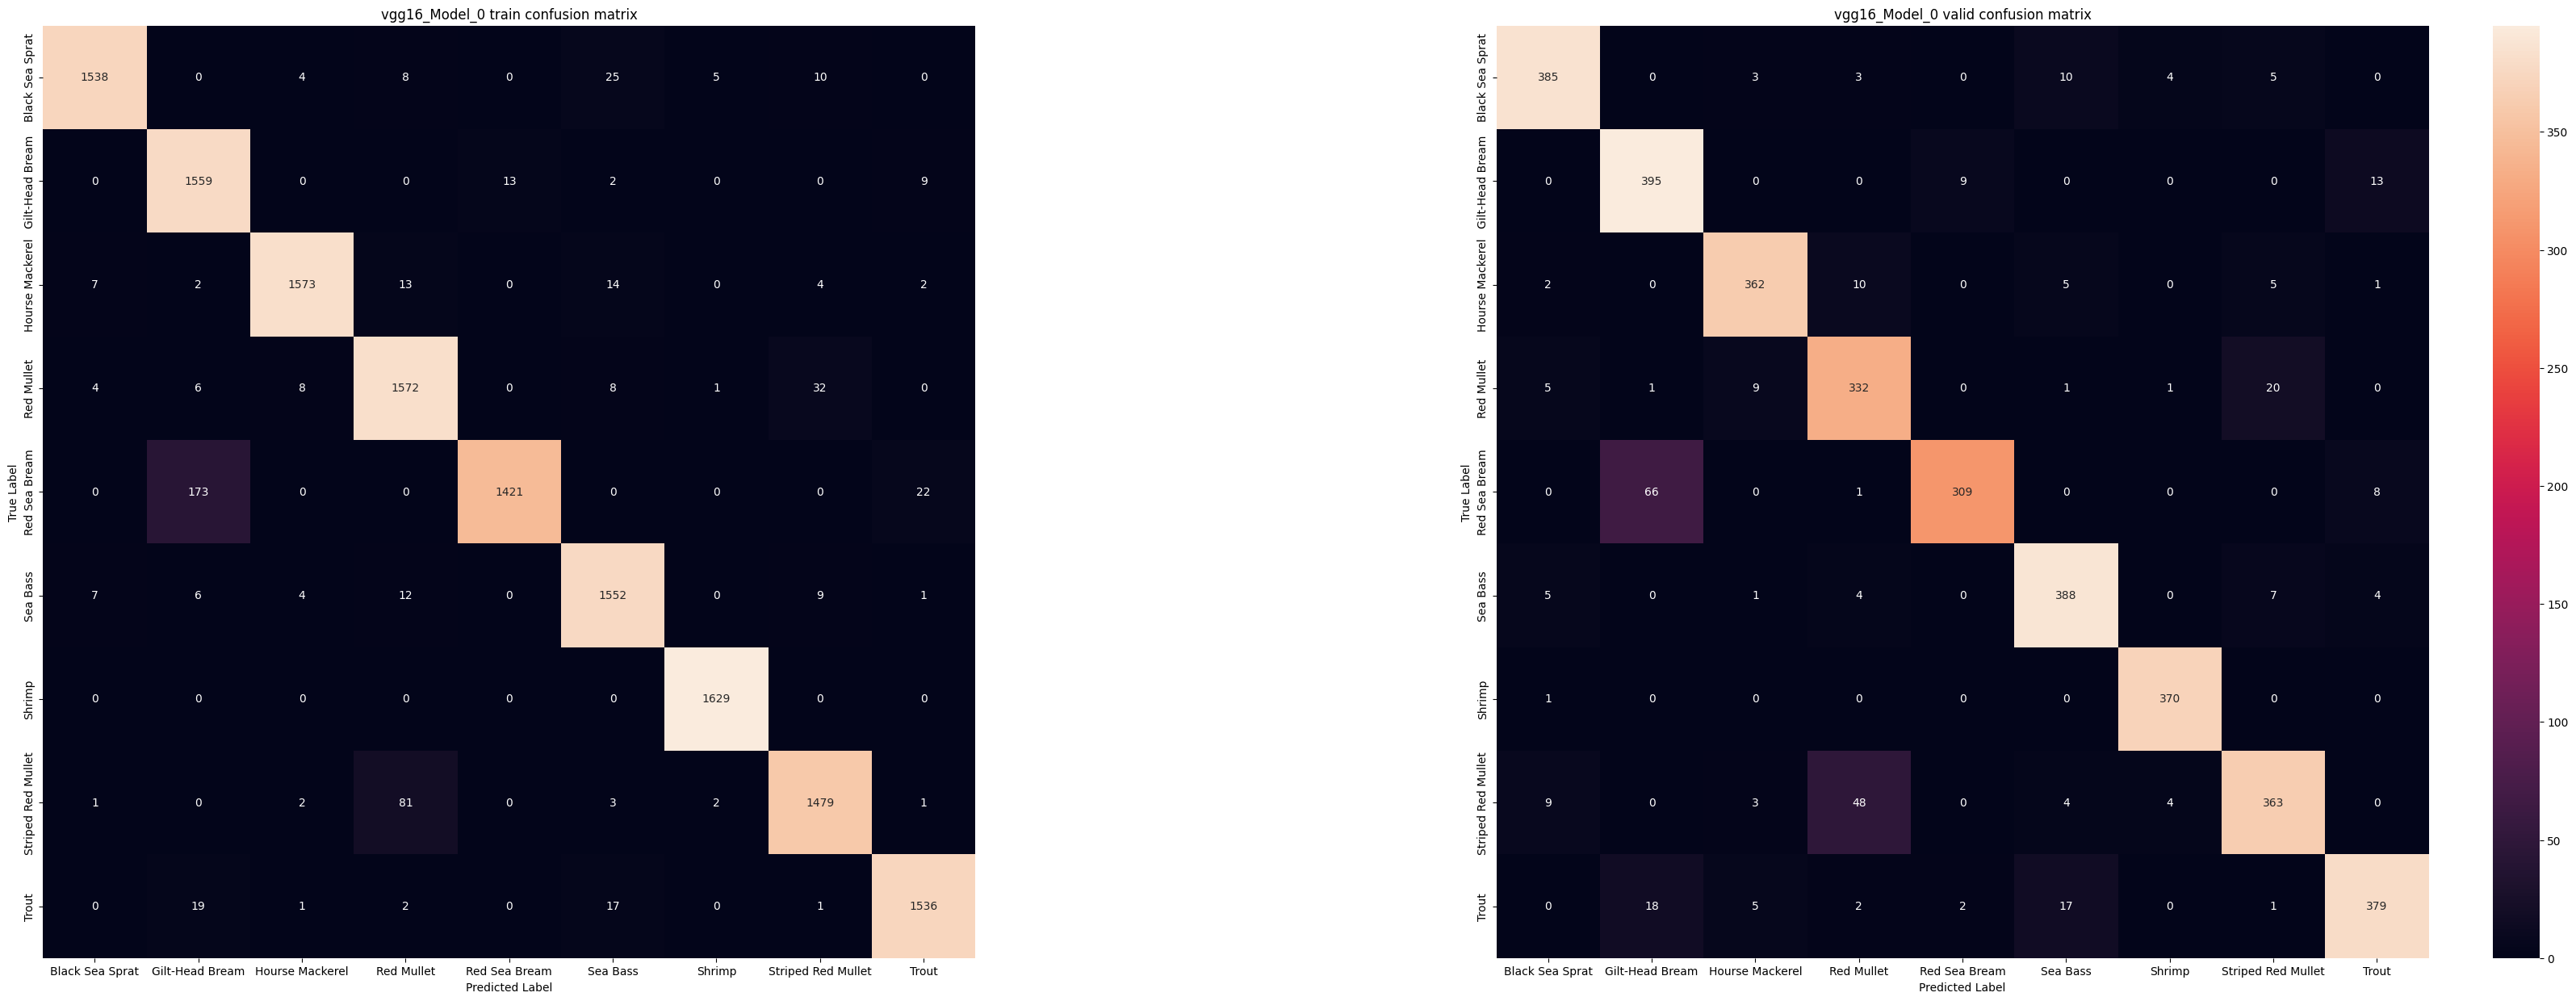

In [40]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

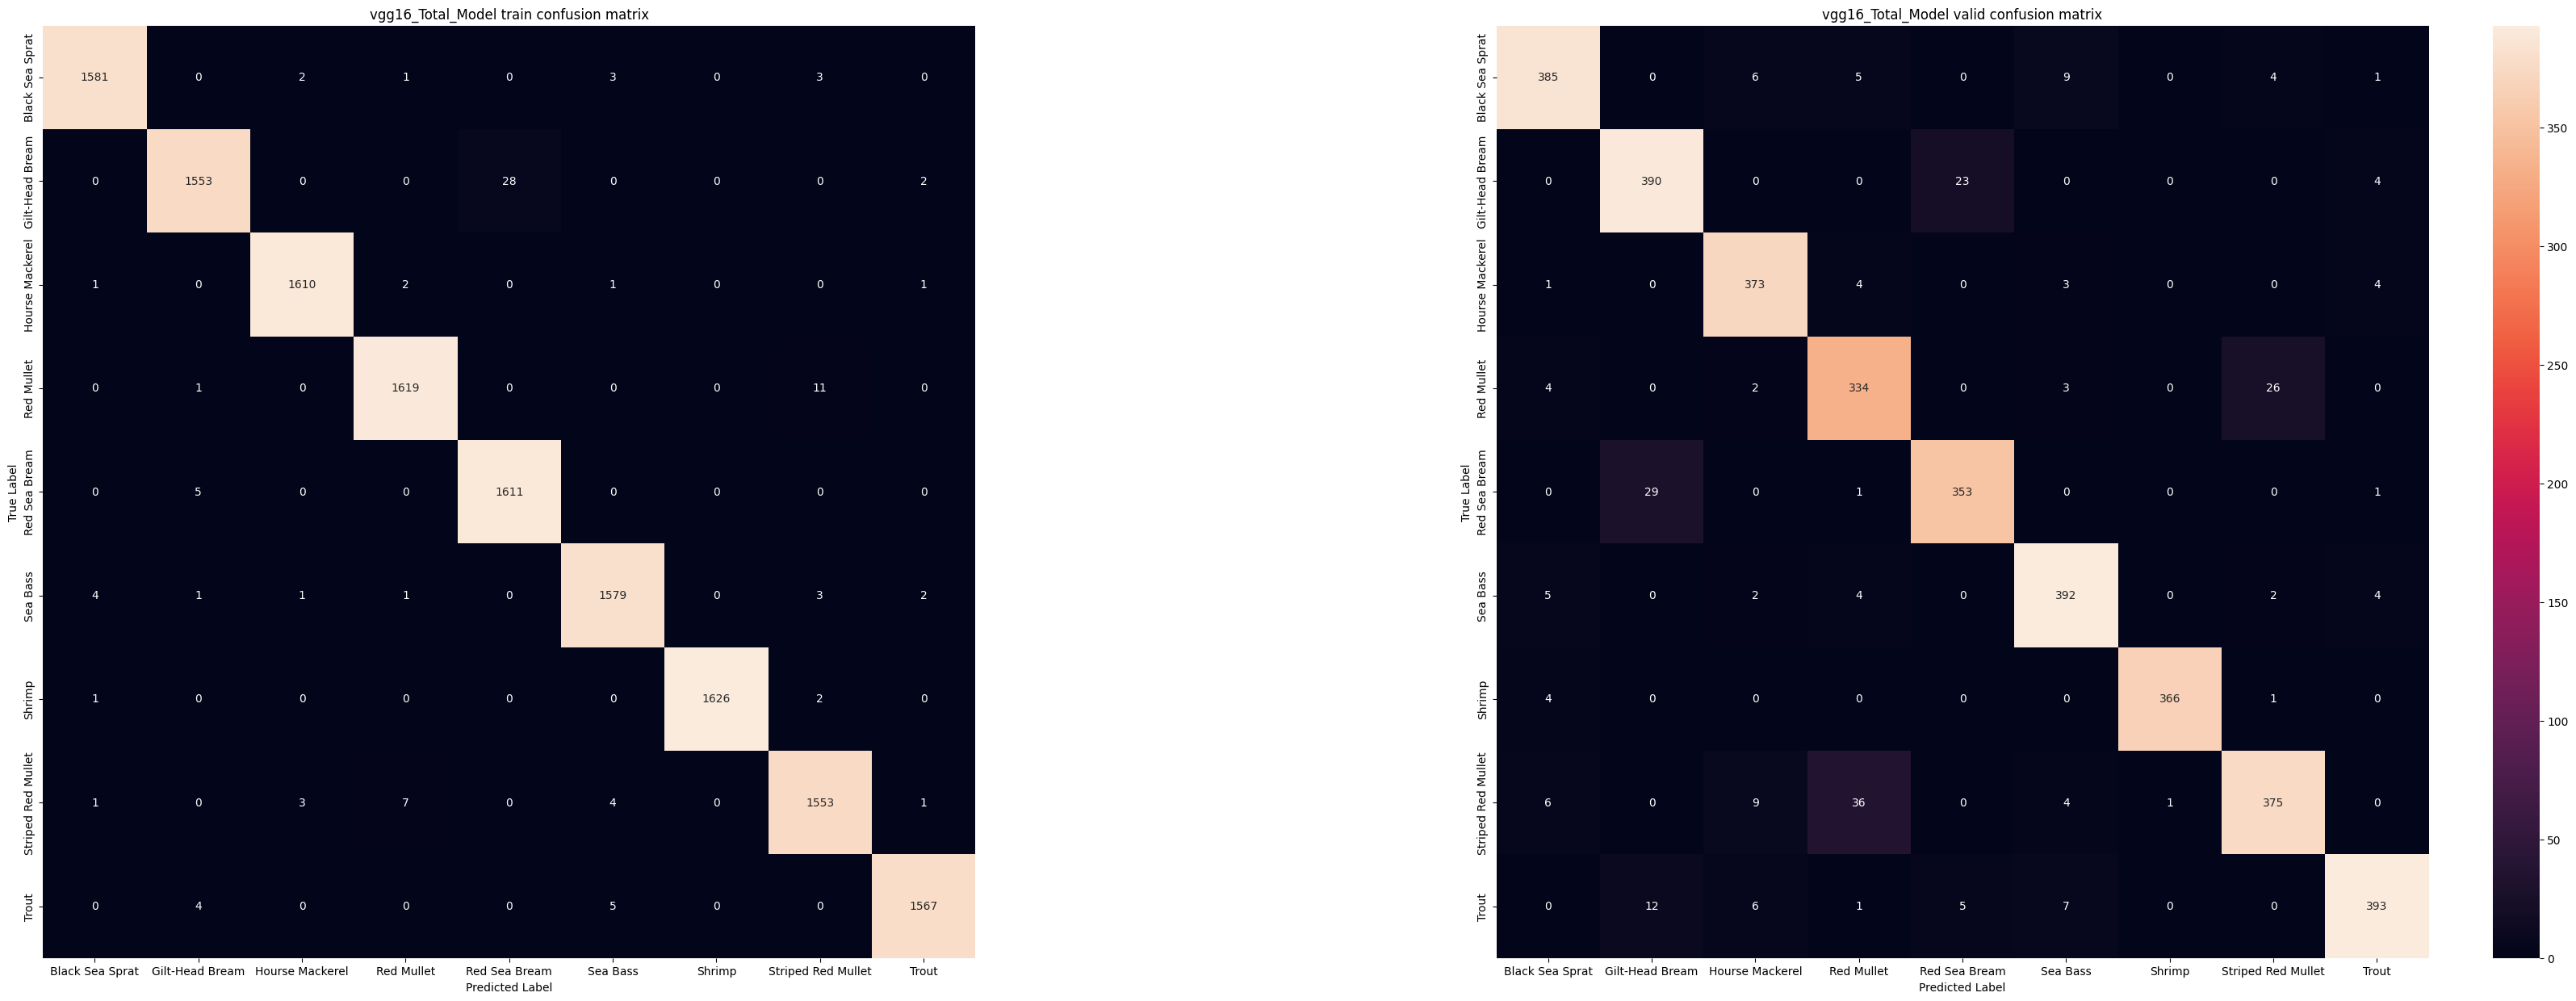

In [41]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

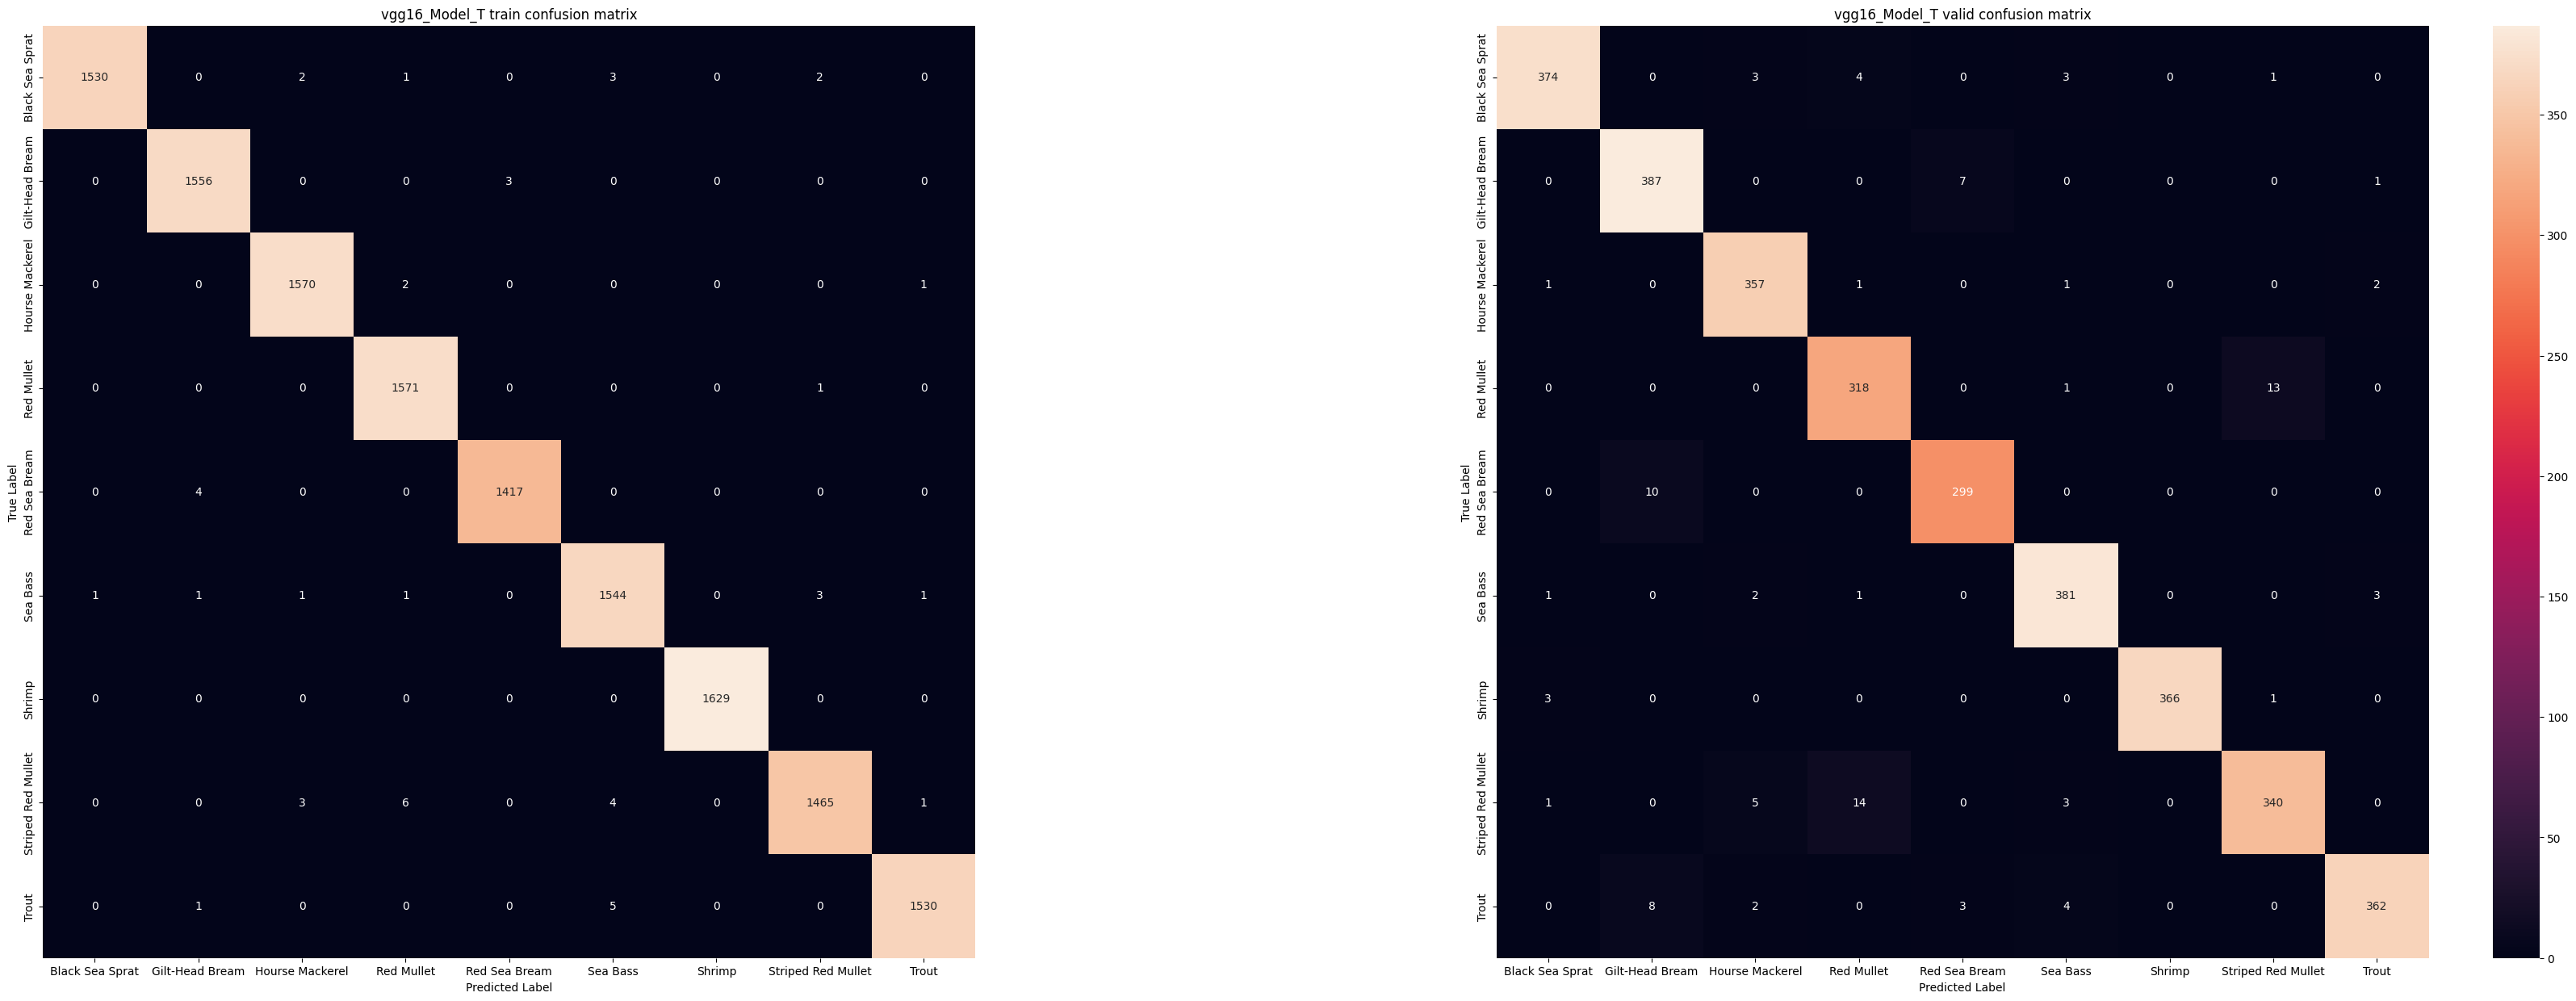

In [42]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

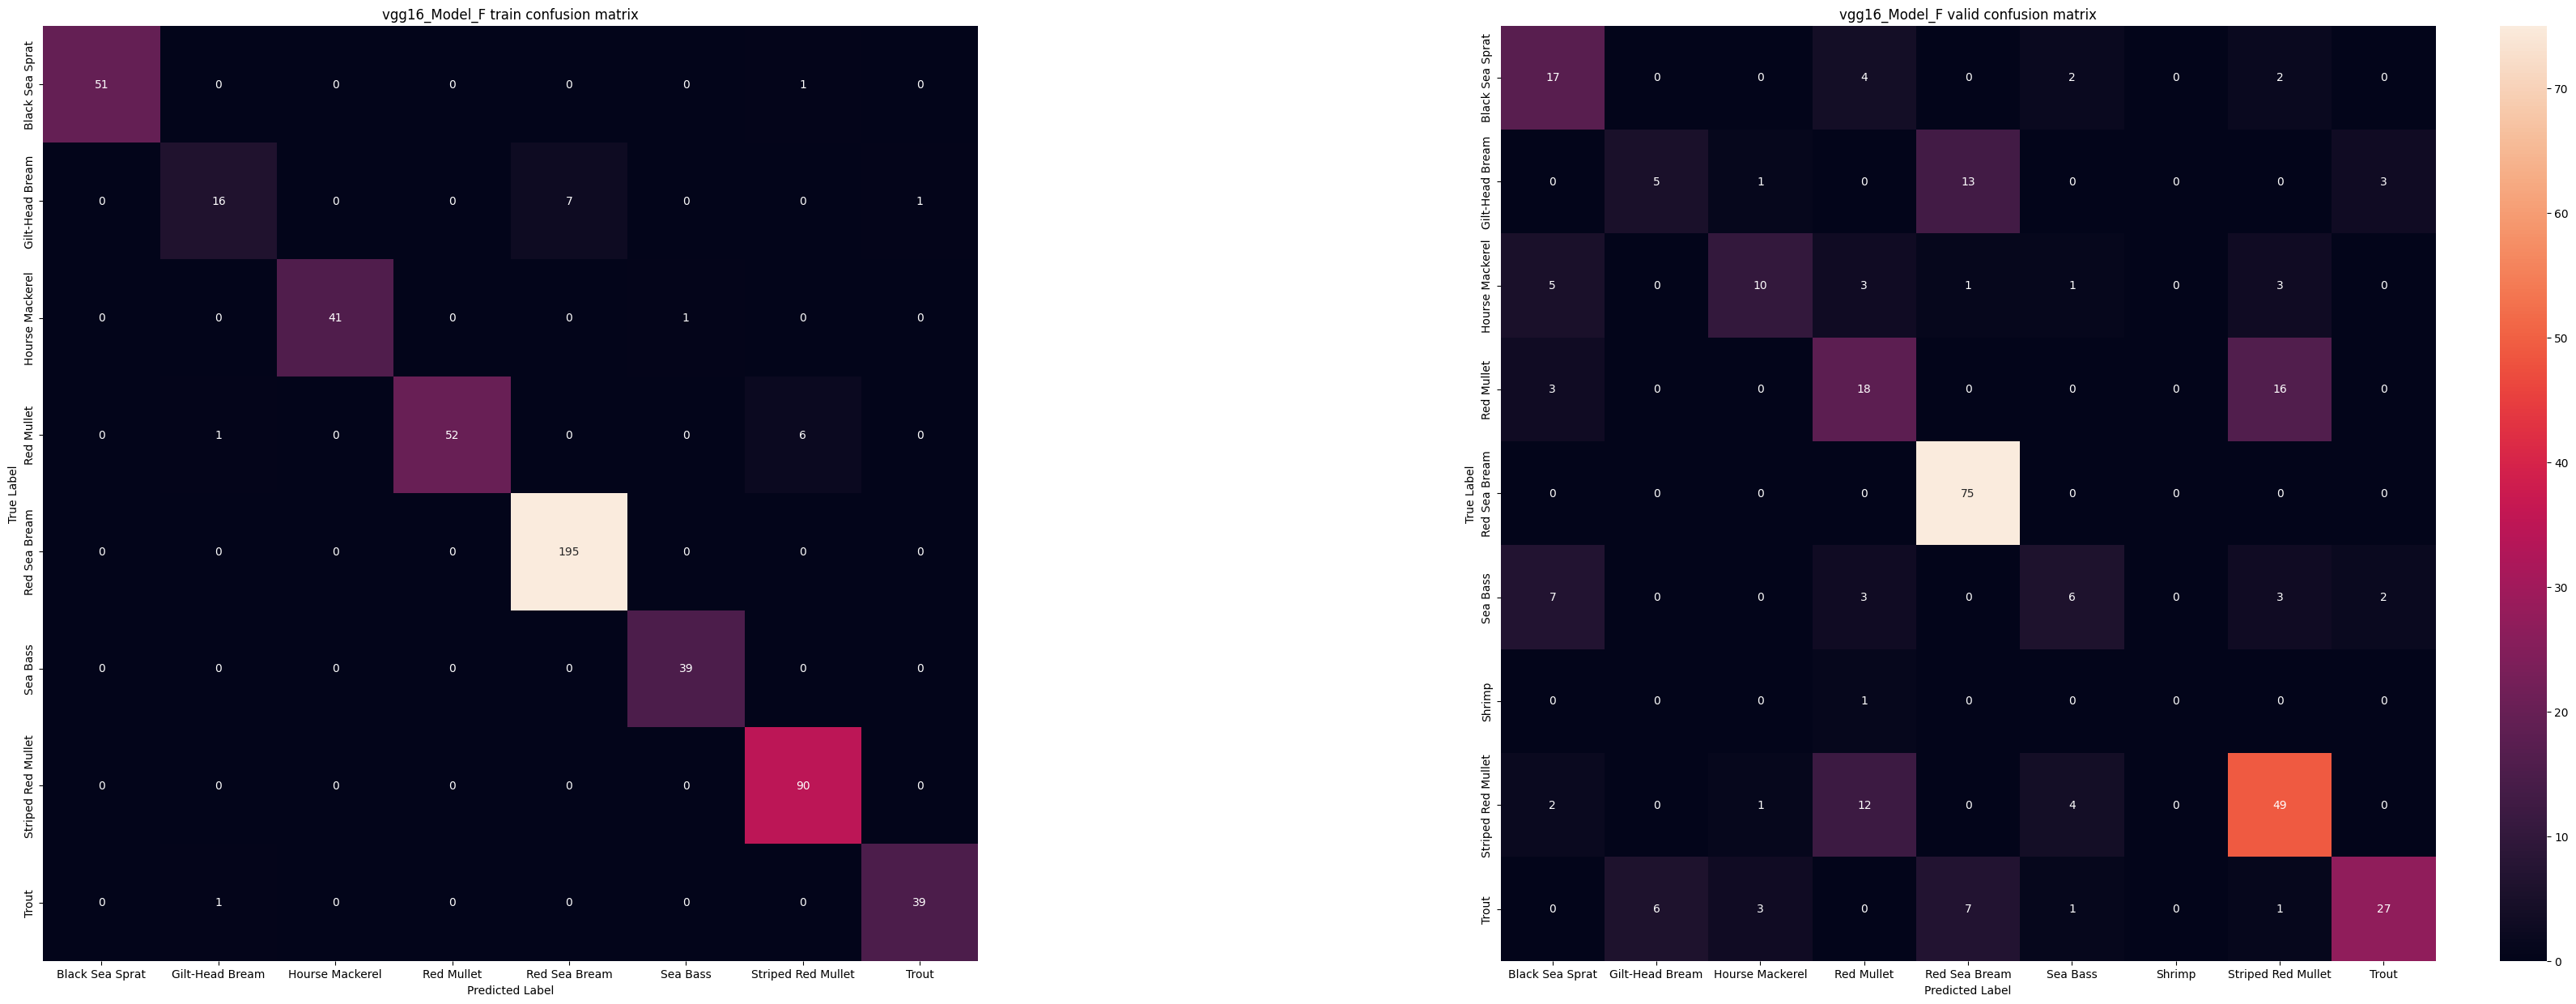

In [43]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [44]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)

            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
        
                if(softmax_decision>0.9):

                    if(pred_decision==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                    if(softmax_F>softmax_T):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [45]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.02960726279788004, 0.9943055555555556, 600, 13800)

In [46]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.4035233969489733, 0.9338888888888889, 92, 3508)

In [47]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [48]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,8072,4,4,4,4,0.999980,1.000000,1.000000,1.000000,True,True,True,True,True
1,773,0,0,0,0,0.985959,0.919393,0.999962,1.000000,True,True,True,True,True
2,14397,7,7,7,7,0.999954,0.998747,0.999351,1.000000,True,True,True,True,True
3,1302,0,0,0,0,0.999986,0.998154,0.999934,1.000000,True,True,True,True,True
4,226,0,0,0,0,0.994279,1.000000,0.999964,1.000000,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14395,12396,6,7,6,6,0.945083,1.000000,1.000000,1.000000,False,True,True,True,True
14396,10028,5,5,5,5,0.985258,1.000000,0.999437,1.000000,True,True,True,True,True
14397,17592,8,8,1,1,0.464762,0.999812,0.645232,0.998785,True,False,False,False,False
14398,15595,7,7,7,7,0.999616,0.999125,0.960978,1.000000,True,True,True,True,True


In [49]:
len(df_results[(df_results['Decision']!=df_results['flag'])&(df_results['Softmax_decision']<0.9)])

41

In [50]:
df_results[(df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
9,11078,5,0,5,5,0.735602,0.999998,0.456877,0.732521,False,True,True,False,True
96,3643,1,4,1,1,0.972947,0.990962,0.679463,0.828629,False,True,True,True,True
224,9745,4,4,4,4,0.997583,0.998315,0.548237,0.543801,True,True,True,False,True
487,9398,4,4,4,4,0.999877,0.997678,0.941252,0.876956,True,True,True,True,True
497,17276,8,1,8,8,0.870291,0.999870,0.992266,0.559613,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14063,1799,0,0,0,0,0.901642,0.998877,0.997810,0.899496,True,True,True,True,True
14162,7145,3,3,3,3,0.985102,0.999969,0.897184,0.662067,True,True,True,True,True
14218,9716,4,4,4,4,0.998917,0.998767,0.498425,0.886375,True,True,True,True,True
14251,16077,8,8,8,8,0.911822,1.000000,0.999714,0.820470,True,True,True,True,True


In [51]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
9,11078,5,0,5,5,0.735602,0.999998,0.456877,0.732521,False,True,True,False,True
45,2482,1,1,1,1,0.877591,1.000000,0.989143,0.901025,True,True,True,False,True
224,9745,4,4,4,4,0.997583,0.998315,0.548237,0.543801,True,True,True,False,True
277,3632,1,4,1,1,0.999380,0.999846,0.630950,0.923109,False,True,True,False,True
433,3491,1,4,1,1,0.993484,1.000000,0.604619,0.913392,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13519,11785,5,0,5,5,0.659718,0.999460,0.987835,0.586835,False,True,True,False,True
13672,5187,2,2,2,2,0.988037,1.000000,0.940097,0.999393,True,True,True,False,True
13740,15097,7,7,7,7,0.999904,0.997230,0.725514,0.826951,True,True,True,False,True
13852,17649,8,8,8,8,0.840210,0.999984,0.942088,0.879730,True,True,True,False,True


In [52]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

4    23
1    22
2    10
7     8
8     8
3     6
5     5
6     3
0     2
Name: Target, dtype: int64

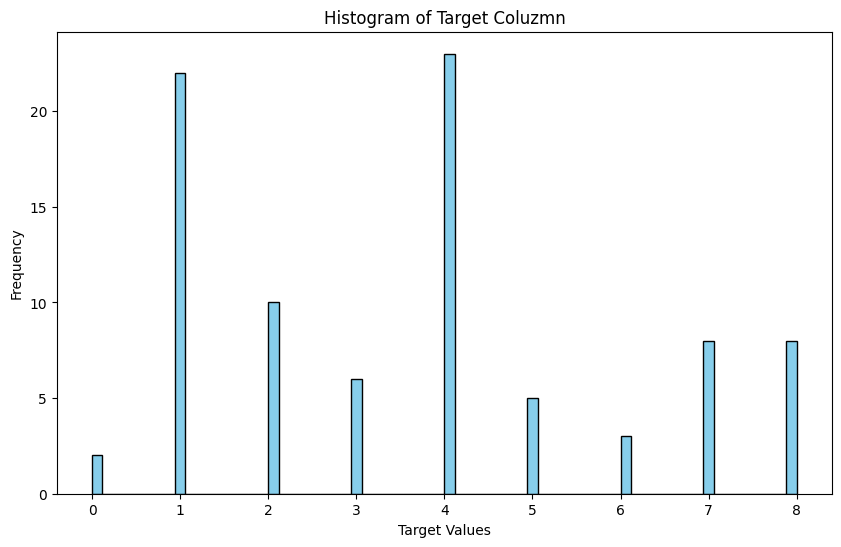

In [53]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [54]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,724,0,0,0,0,0.999981,0.995726,0.978640,1.000000,True,True,True,True,True
1,9272,4,4,4,4,0.999997,0.999451,0.904383,1.000000,True,True,True,True,True
2,2006,1,1,1,1,0.520914,1.000000,0.999987,1.000000,True,True,True,True,True
3,2326,1,1,1,1,0.970064,1.000000,0.999996,1.000000,True,True,True,True,True
4,6748,3,7,3,3,0.999998,1.000000,1.000000,1.000000,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,11214,5,5,5,5,0.648303,1.000000,0.996526,1.000000,True,True,True,True,True
3596,321,0,0,0,0,0.999838,1.000000,0.999787,1.000000,True,True,True,True,True
3597,16236,8,4,8,8,0.955379,1.000000,0.913822,1.000000,False,True,True,True,True
3598,8941,4,4,4,4,0.999973,1.000000,0.721555,0.999995,True,True,True,True,True


In [55]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
12,3562,1,4,1,1,0.999963,0.999977,0.997233,0.958515,False,True,True,False,True
20,7438,3,3,2,2,0.534510,0.998934,0.996890,1.000000,True,False,False,True,False
30,17404,8,4,8,1,0.710429,0.530605,0.800086,1.000000,False,True,False,True,False
42,15829,7,7,2,7,0.999195,0.974076,0.319822,0.949346,True,False,True,False,True
64,9280,4,4,4,1,0.999974,0.998794,0.567360,1.000000,True,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3523,7291,3,7,3,7,0.993995,0.989607,0.809581,1.000000,False,True,False,True,False
3539,11738,5,5,5,5,0.952686,1.000000,0.990849,0.525195,True,True,True,False,True
3554,16623,8,8,8,5,0.985029,0.999998,0.687910,0.999675,True,True,False,True,False
3568,15511,7,7,3,3,1.000000,0.978590,0.982355,0.999936,True,False,False,True,False


In [56]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

7    58
4    52
8    46
3    38
1    31
5    26
0    25
2    23
6     1
Name: Target, dtype: int64

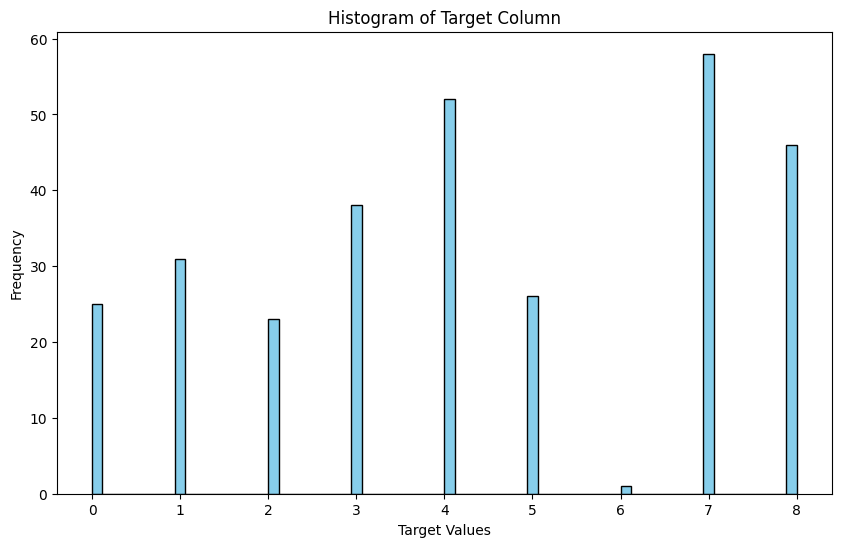

In [57]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()